# Results comparison: GAN vs SwinIR vs SwinIR+FiLM

Loads `eval_*.json` reports from each model's output directory and builds the
publication figures for `reports/swinir/ABLATIONS.md`.

Run `scripts/evaluate.py` for each checkpoint first.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

EVAL_FILES = {
    'gan': Path('../../outputs/final_run/eval_val.json'),  # adjust if you have one
    'swinir_base': Path('../outputs/swinir_base/eval_val.json'),
    'swinir_film': Path('../outputs/swinir_film/eval_val.json'),
}

rows = []
for name, p in EVAL_FILES.items():
    if p.exists():
        rows.append({'model': name, **json.loads(p.read_text())})
df = pd.DataFrame(rows)
df

""


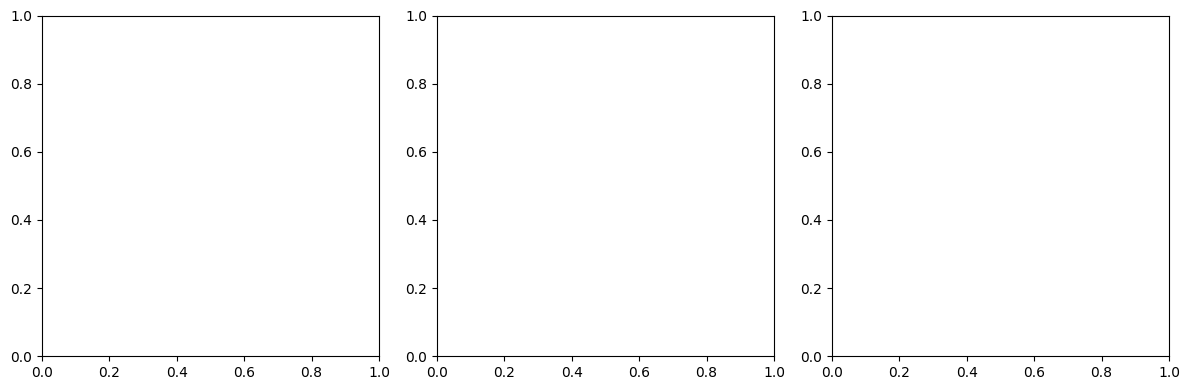

In [2]:
# Bar plot of L1 raw, PSNR, energy response
metrics = ['l1_raw', 'psnr', 'energy_response_mean']
fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
for ax, m in zip(axes, metrics):
    if m in df.columns:
        df.plot.bar(x='model', y=m, ax=ax, legend=False)
        ax.set_title(m)
        ax.set_xlabel('')
plt.tight_layout()

## Per-class response gap

The GAN baseline had a per-class gap of 0.0091. FiLM conditioning should
narrow this further.